In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from utils.logger import get_logger
_logs = get_logger(__name__)

In [2]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

In [3]:
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(os.path.join(ft_dir, '**/*.parquet'), 
               recursive = True)
df = dd.read_parquet(ft_glob).compute().reset_index()

In [5]:
type(df)

pandas.core.frame.DataFrame

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [14]:
df.sample(n = 5)

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1
345639,WABC,2008-05-14,57.220001,58.02,56.700001,56.820000,40.070446,122400.0,WABC.csv,2008,57.130001
228959,OLEM,2016-12-05,17.080000,17.08,16.809999,16.809999,16.809999,900.0,OLEM.csv,2016,16.910000
49875,BPMX,2020-02-18,0.396000,0.40,0.385000,0.390000,0.390000,401000.0,BPMX.csv,2020,0.404000
252131,REI,2015-09-22,9.830000,10.15,9.620000,9.700000,9.700000,52900.0,REI.csv,2015,9.990000
289515,SRE,2015-11-09,100.699997,100.93,99.779999,100.349998,87.572830,1306000.0,SRE.csv,2015,100.919998


In [15]:
import random
random.seed(42)
sample_tickers = random.sample(df['ticker'].unique().tolist(), 30)
df = df[df['ticker'].isin(sample_tickers)]
simple_sample_dt = df.sample(frac = 0.1)
simple_sample_dt.shape, df.shape

((13005, 11), (130053, 11))

Look at the distribution of tickers.

<Axes: xlabel='ticker'>

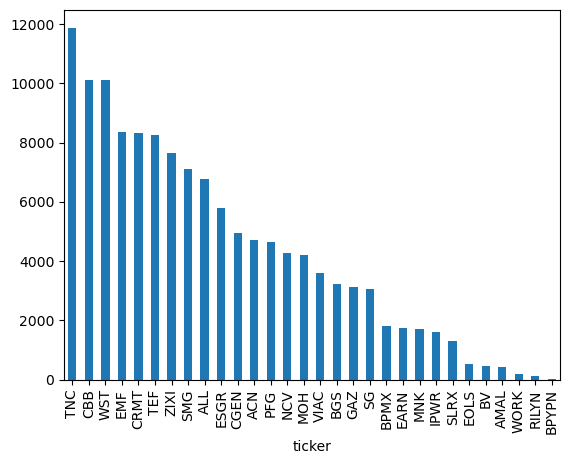

In [21]:
df['ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='ticker'>

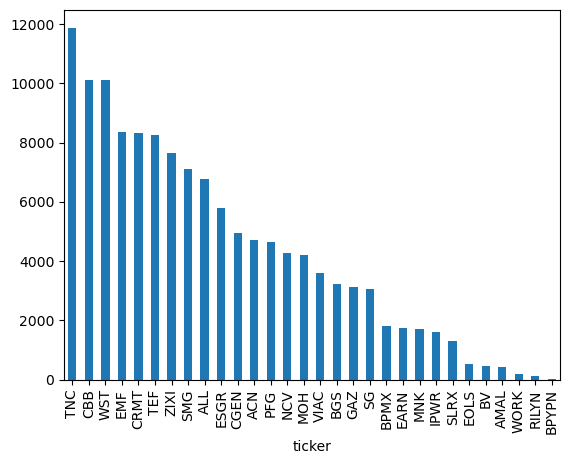

In [16]:
df['ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='ticker'>

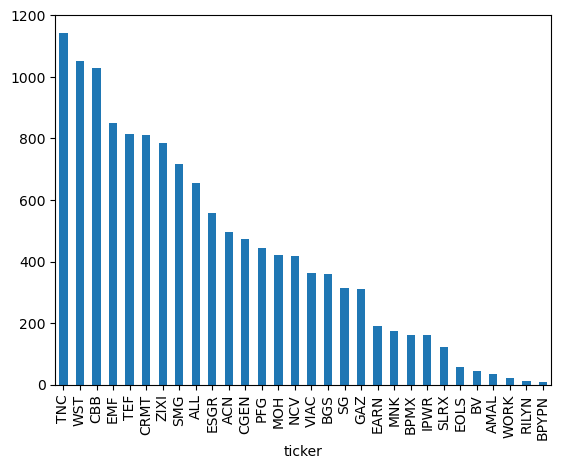

In [22]:
simple_sample_dt['ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

<Axes: xlabel='ticker'>

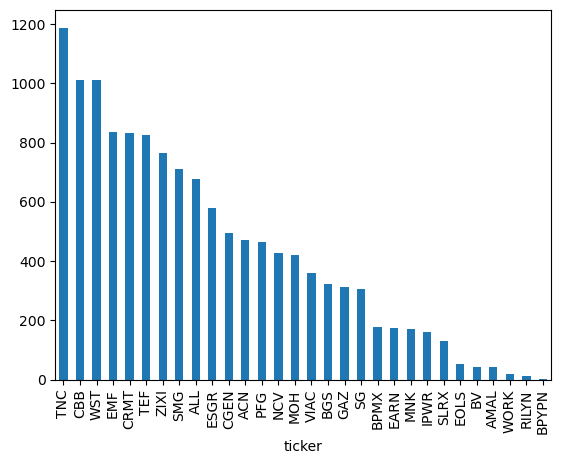

In [23]:
strat_sample_dt = df.groupby(['ticker']).sample(frac = 0.1)
strat_sample_dt['ticker'].value_counts().plot(kind='bar')

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

C:\Users\JesusCalderon\AppData\Local\Temp\ipykernel_14740\1783207470.py:2: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  strat_sample_dd = (dd_dt


<Axes: xlabel='ticker'>

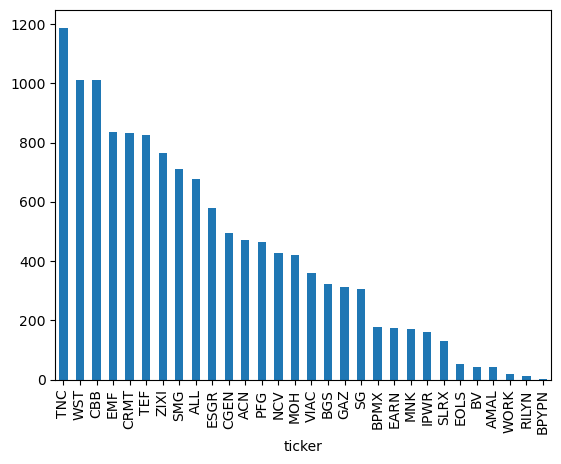

In [24]:
dd_dt = dd.read_parquet(ft_glob)
strat_sample_dd = (dd_dt
                      .groupby('ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac = 0.1))
                      .compute()
                      .reset_index())
strat_sample_dd[strat_sample_dd['ticker'].isin(sample_tickers)]['ticker'].value_counts().plot(kind='bar')